# **Project Overview**

# 🌾 AI-Based Crop Production Trend Prediction

## Problem Statement
Farmers and agricultural planners lack predictive insights on future crop production trends, leading to overproduction, shortages, and unstable prices. Existing systems provide only historical data without forward-looking guidance.

## Objective
To build an AI-based decision support system that predicts future crop production trends and helps farmers and planners anticipate surplus and shortages before cultivation.

## Key Outcomes
- Predict crop production trends using historical data
- Identify potential surplus or shortage scenarios
- Provide simple, actionable crop planning insights

## Scope (MVP)
- Single crop and single region
- Historical production data
- Trend prediction and visual insights

## Out of Scope
- Real-time price prediction
- Weather forecasting
- Individual farmer-level personalization

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [127]:
import pandas as pd
df = pd.read_csv("/content/crop-data.csv")
df.head(30)

,Crop,State,Season,Area-2021-22,Area-2022-23,Area-2023-24,Area-2024-25,Area-2025-26,Production-2021-22,Production-2022-23,Production-2023-24,Production-2024-25,Production-2025-26,Yield-2021-22,Yield-2022-23,Yield-2023-24,Yield-2024-25,Yield-2025-26
0,Rice,Andaman And Nicobar Islands,Kharif,0.06,0.05,0.05,0.04,NaN,0.13,0.11,0.10,0.09,NaN,2133.0,2107.0,2100.0,2060.0,NaN
1,Rice,Andaman And Nicobar Islands,Rabi,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Rice,Andaman And Nicobar Islands,Total,0.06,0.05,0.05,0.04,NaN,0.13,0.11,0.10,0.09,NaN,2133.0,2107.0,2100.0,2060.0,NaN
3,Rice,Andhra Pradesh,Kharif,15.08,14.52,13.47,14.04,14.77,43.26,49.86,46.95,50.31,52.92,2869.0,3434.0,3485.0,3583.0,3583.0
4,Rice,Andhra Pradesh,Rabi,7.81,6.77,5.73,6.73,NaN,34.37,29.56,26.46,31.29,NaN,4401.0,4366.0,4616.0,4649.0,NaN
5,Rice,Andhra Pradesh,Total,22.89,21.29,19.21,20.77,14.77,77.64,79.42,73.42,81.59,52.92,3392.0,3730.0,3822.0,3928.0,3583.0
6,Rice,Arunachal Pradesh,Kharif,1.36,1.36,1.37,1.37,NaN,2.51,2.53,2.54,2.55,NaN,1852.0,1857.0,1858.0,1859.0,NaN
7,Rice,Arunachal Pradesh,Rabi,0.01,0.01,0.01,0.00,NaN,0.01,0.01,0.01,0.00,NaN,1343.0,1345.0,1347.0,449.0,NaN
8,Rice,Arunachal Pradesh,Total,1.36,1.37,1.37,1.38,NaN,2.52,2.54,2.55,2.56,NaN,1849.0,1854.0,1856.0,1856.0,NaN
9,Rice,Assam,Kharif,19.83,19.43,19.18,18.21,18.15,35.38,45.18,43.74,37.60,39.35,1784.0,2326.0,2281.0,2065.0,2168.0


In [128]:
df.shape

(3442, 18)

In [129]:
df.columns

Index(['Crop', 'State', 'Season', 'Area-2021-22', 'Area-2022-23',
       'Area-2023-24', 'Area-2024-25', 'Area-2025-26', 'Production-2021-22',
       'Production-2022-23', 'Production-2023-24', 'Production-2024-25',
       'Production-2025-26', 'Yield-2021-22', 'Yield-2022-23', 'Yield-2023-24',
       'Yield-2024-25', 'Yield-2025-26'],
      dtype='object')

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3442 entries, 0 to 3441
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Crop                3442 non-null   object 
 1   State               3442 non-null   object 
 2   Season              3442 non-null   object 
 3   Area-2021-22        2743 non-null   float64
 4   Area-2022-23        2154 non-null   float64
 5   Area-2023-24        2161 non-null   float64
 6   Area-2024-25        2169 non-null   float64
 7   Area-2025-26        950 non-null    float64
 8   Production-2021-22  3157 non-null   float64
 9   Production-2022-23  2154 non-null   float64
 10  Production-2023-24  2161 non-null   float64
 11  Production-2024-25  2169 non-null   float64
 12  Production-2025-26  950 non-null    float64
 13  Yield-2021-22       2743 non-null   float64
 14  Yield-2022-23       2154 non-null   float64
 15  Yield-2023-24       2161 non-null   float64
 16  Yield-

In [131]:
df.isnull().sum()

,0
Crop,0
State,0
Season,0
Area-2021-22,699
Area-2022-23,1288
Area-2023-24,1281
Area-2024-25,1273
Area-2025-26,2492
Production-2021-22,285
Production-2022-23,1288


In [132]:
df = df.dropna(subset=['Production-2023-24'])

In [133]:
# Clean column names to remove BOM characters and quotes
df.columns = df.columns.str.replace('ï»¿', '', regex=False).str.replace('"', '', regex=False).str.strip()

# Now filter using the cleaned 'Crop' column name
df_crop = df[(df['Crop'] == 'Rice') & (df['State'] == 'Andhra Pradesh')]

In [134]:
df_crop = df[(df['Crop'] == 'Rice') & (df['State'] == 'Andhra Pradesh')]
display(df_crop.head())

,Crop,State,Season,Area-2021-22,Area-2022-23,Area-2023-24,Area-2024-25,Area-2025-26,Production-2021-22,Production-2022-23,Production-2023-24,Production-2024-25,Production-2025-26,Yield-2021-22,Yield-2022-23,Yield-2023-24,Yield-2024-25,Yield-2025-26
3,Rice,Andhra Pradesh,Kharif,15.08,14.52,13.47,14.04,14.77,43.26,49.86,46.95,50.31,52.92,2869.0,3434.0,3485.0,3583.0,3583.0
4,Rice,Andhra Pradesh,Rabi,7.81,6.77,5.73,6.73,NaN,34.37,29.56,26.46,31.29,NaN,4401.0,4366.0,4616.0,4649.0,NaN
5,Rice,Andhra Pradesh,Total,22.89,21.29,19.21,20.77,14.77,77.64,79.42,73.42,81.59,52.92,3392.0,3730.0,3822.0,3928.0,3583.0


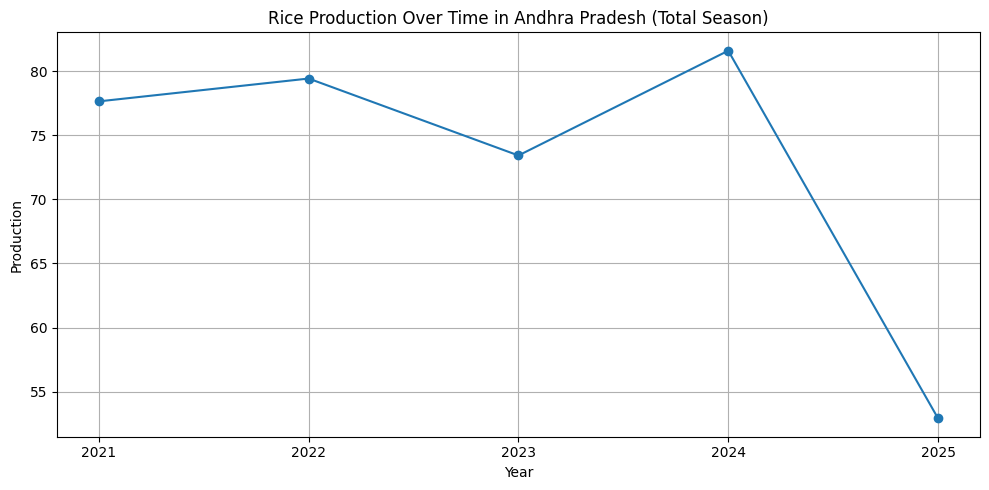

In [135]:
import matplotlib.pyplot as plt
import pandas as pd

# Filter for 'Total' season to get overall production trend
df_crop_total = df_crop[df_crop['Season'] == 'Total'].copy()

# Identify production columns for melting
production_cols = [col for col in df_crop_total.columns if 'Production-' in col]

# Melt the DataFrame to transform year-specific columns into 'Year' and 'Production' columns
df_melted = df_crop_total.melt(id_vars=['Crop', 'State', 'Season'],
                               value_vars=production_cols,
                               var_name='Year_Col',
                               value_name='Production')

# Extract the year from the 'Year_Col' (e.g., 'Production-2021-22' -> 2021)
df_melted['Year'] = df_melted['Year_Col'].str.extract(r'(\d{4})').astype(int)

# Drop rows with NaN production values before plotting
df_melted.dropna(subset=['Production'], inplace=True)

# Sort by year for proper plotting
df_melted = df_melted.sort_values(by='Year')

plt.figure(figsize=(10,5))
plt.plot(df_melted['Year'], df_melted['Production'], marker='o')
plt.title('Rice Production Over Time in Andhra Pradesh (Total Season)')
plt.xlabel('Year')
plt.ylabel('Production')
plt.grid(True)
plt.xticks(df_melted['Year'].unique()) # Ensure all years are shown as ticks
plt.tight_layout()
plt.show()

# **Data Loading**

## DATASET SCHEMA

The dataset represents historical agricultural data for the crop **Rice** in India.

### STRUCTURE
- Each row represents:
  Crop × State × Season

- Data is provided in **wide format**, with separate columns for each year.

### CORE IDENTIFIER COLUMNS
- Crop        → string (always "Rice")
- State       → string (Indian state / region name)
- Season      → categorical ("Kharif", "Rabi", "Summer", "Total")

### AREA COLUMNS (in million hectares)
- Area-2021-22
- Area-2022-23
- Area-2023-24
- Area-2024-25
- Area-2025-26

### PRODUCTION COLUMNS (in million tonnes)
- Production-2021-22
- Production-2022-23
- Production-2023-24
- Production-2024-25
- Production-2025-26

### YIELD COLUMNS (kg/ha)
- Yield-2021-22
- Yield-2022-23
- Yield-2023-24
- Yield-2024-25
- Yield-2025-26

### IMPORTANT DATA NOTES
- Some rows may contain missing values (especially for certain seasons or years)
- "Total" season rows represent aggregated values
- Not all states have all seasons
- The dataset includes "All India" aggregated rows

### DATA TRANSFORMATION RULES (MANDATORY)
- Convert the dataset from **wide format to long format** before modeling
- Create a single `Year` column (numeric)
- Create a single `Production` column (numeric)
- Drop rows with missing production values
- Do NOT fabricate or impute data unless explicitly instructed

## 📂 Data Loading

In this section, we load the historical crop production dataset and perform basic inspection to understand its structure.

In [136]:
import pandas as pd

# Load dataset (update path if needed)
df = pd.read_csv('/content/crop-data.csv')

# Preview data
df.head()

,Crop,State,Season,Area-2021-22,Area-2022-23,Area-2023-24,Area-2024-25,Area-2025-26,Production-2021-22,Production-2022-23,Production-2023-24,Production-2024-25,Production-2025-26,Yield-2021-22,Yield-2022-23,Yield-2023-24,Yield-2024-25,Yield-2025-26
0,Rice,Andaman And Nicobar Islands,Kharif,0.06,0.05,0.05,0.04,NaN,0.13,0.11,0.10,0.09,NaN,2133.0,2107.0,2100.0,2060.0,NaN
1,Rice,Andaman And Nicobar Islands,Rabi,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Rice,Andaman And Nicobar Islands,Total,0.06,0.05,0.05,0.04,NaN,0.13,0.11,0.10,0.09,NaN,2133.0,2107.0,2100.0,2060.0,NaN
3,Rice,Andhra Pradesh,Kharif,15.08,14.52,13.47,14.04,14.77,43.26,49.86,46.95,50.31,52.92,2869.0,3434.0,3485.0,3583.0,3583.0
4,Rice,Andhra Pradesh,Rabi,7.81,6.77,5.73,6.73,NaN,34.37,29.56,26.46,31.29,NaN,4401.0,4366.0,4616.0,4649.0,NaN


In [137]:
display(df.columns)

Index(['Crop', 'State', 'Season', 'Area-2021-22', 'Area-2022-23',
       'Area-2023-24', 'Area-2024-25', 'Area-2025-26', 'Production-2021-22',
       'Production-2022-23', 'Production-2023-24', 'Production-2024-25',
       'Production-2025-26', 'Yield-2021-22', 'Yield-2022-23', 'Yield-2023-24',
       'Yield-2024-25', 'Yield-2025-26'],
      dtype='object')

# ***Data Cleaning & Preprocessing***

## MODELING CONTEXT

- This is a **time-based regression problem**
- Independent variable: Year
- Target variable: Production
- Modeling goal: learn trends and forecast future production
- Simplicity and explainability are prioritized over complexity

## 🧹 Data Cleaning & Preprocessing

This step ensures the dataset is clean, consistent, and suitable for analysis and modeling.
We remove missing values, filter relevant records, and prepare the data for time-based analysis.

In [138]:
# Basic information
df.info()

# Filter to MVP scope (example: Rice in Andhra Pradesh) and 'Total' season
# Use the correct column name 'ï»¿"Crop"'
df_filtered = df[(df['Crop'] == 'Rice') & (df['State'] == 'Andhra Pradesh') & (df['Season'] == 'Total')].copy()

# Identify production columns for melting
production_cols = [col for col in df_filtered.columns if 'Production-' in col]

# Melt the DataFrame to transform year-specific columns into 'Year_Col' and 'Production' columns
df_melted_cleaned = df_filtered.melt(id_vars=['Crop', 'State', 'Season'],
                                     value_vars=production_cols,
                                     var_name='Year_Col',
                                     value_name='Production')

# Extract the year from the 'Year_Col' (e.g., 'Production-2021-22' -> 2021)
df_melted_cleaned['Year'] = df_melted_cleaned['Year_Col'].str.extract(r'(\d{4})').astype(int)

# Remove rows with missing production values (now 'Production' column exists)
df_melted_cleaned.dropna(subset=['Production'], inplace=True)

# Sort by year for time-series consistency (now 'Year' column exists)
df_melted_cleaned = df_melted_cleaned.sort_values(by='Year')

# Assign the cleaned and melted DataFrame back to df for subsequent steps
df = df_melted_cleaned.copy()

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3442 entries, 0 to 3441
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Crop                3442 non-null   object 
 1   State               3442 non-null   object 
 2   Season              3442 non-null   object 
 3   Area-2021-22        2743 non-null   float64
 4   Area-2022-23        2154 non-null   float64
 5   Area-2023-24        2161 non-null   float64
 6   Area-2024-25        2169 non-null   float64
 7   Area-2025-26        950 non-null    float64
 8   Production-2021-22  3157 non-null   float64
 9   Production-2022-23  2154 non-null   float64
 10  Production-2023-24  2161 non-null   float64
 11  Production-2024-25  2169 non-null   float64
 12  Production-2025-26  950 non-null    float64
 13  Yield-2021-22       2743 non-null   float64
 14  Yield-2022-23       2154 non-null   float64
 15  Yield-2023-24       2161 non-null   float64
 16  Yield-

,Crop,State,Season,Year_Col,Production,Year
0,Rice,Andhra Pradesh,Total,Production-2021-22,77.64,2021
1,Rice,Andhra Pradesh,Total,Production-2022-23,79.42,2022
2,Rice,Andhra Pradesh,Total,Production-2023-24,73.42,2023
3,Rice,Andhra Pradesh,Total,Production-2024-25,81.59,2024
4,Rice,Andhra Pradesh,Total,Production-2025-26,52.92,2025


In [139]:
columns = [
    "Crop", "State", "Season",
    "Area_2021", "Area_2022", "Area_2023", "Area_2024", "Area_2025",
    "Prod_2021", "Prod_2022", "Prod_2023", "Prod_2024", "Prod_2025",
    "Yield_2021", "Yield_2022", "Yield_2023", "Yield_2024", "Yield_2025"
]

In [140]:
data = [
    ["Rice", "Andhra Pradesh", "Kharif",
     15.08, 14.52, 13.47, 14.04, 14.77,
     43.26, 49.86, 46.95, 50.31, 52.92,
     2869, 3434, 3485, 3583, 3583],

    ["Rice", "Andhra Pradesh", "Rabi",
     7.81, 6.77, 5.73, 6.73, np.nan,
     34.37, 29.56, 26.46, 31.29, np.nan,
     4401, 4366, 4616, 4649, np.nan],

    ["Rice", "Andhra Pradesh", "Total",
     22.89, 21.29, 19.21, 20.77, 14.77,
     77.64, 79.42, 73.42, 81.59, 52.92,
     3392, 3730, 3822, 3928, 3583],
]

In [141]:
df_wide = pd.DataFrame(data, columns=columns)
df_wide

,Crop,State,Season,Area_2021,Area_2022,Area_2023,Area_2024,Area_2025,Prod_2021,Prod_2022,Prod_2023,Prod_2024,Prod_2025,Yield_2021,Yield_2022,Yield_2023,Yield_2024,Yield_2025
0,Rice,Andhra Pradesh,Kharif,15.08,14.52,13.47,14.04,14.77,43.26,49.86,46.95,50.31,52.92,2869,3434,3485,3583,3583.0
1,Rice,Andhra Pradesh,Rabi,7.81,6.77,5.73,6.73,NaN,34.37,29.56,26.46,31.29,NaN,4401,4366,4616,4649,NaN
2,Rice,Andhra Pradesh,Total,22.89,21.29,19.21,20.77,14.77,77.64,79.42,73.42,81.59,52.92,3392,3730,3822,3928,3583.0


In [142]:
prod_cols = ["Prod_2021", "Prod_2022", "Prod_2023", "Prod_2024", "Prod_2025"]

df_long = df_wide.melt(
    id_vars=["Crop", "State", "Season"],
    value_vars=prod_cols,
    var_name="Year",
    value_name="Production"
)

In [143]:
df_long["Year"] = df_long["Year"].str.extract("(\d+)").astype(int) + 2000
df_long = df_long.dropna()
df_long

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-1087688854.py:1: SyntaxWarning: invalid escape sequence '\d'
  df_long["Year"] = df_long["Year"].str.extract("(\d+)").astype(int) + 2000


,Crop,State,Season,Year,Production
0,Rice,Andhra Pradesh,Kharif,4021,43.26
1,Rice,Andhra Pradesh,Rabi,4021,34.37
2,Rice,Andhra Pradesh,Total,4021,77.64
3,Rice,Andhra Pradesh,Kharif,4022,49.86
4,Rice,Andhra Pradesh,Rabi,4022,29.56
5,Rice,Andhra Pradesh,Total,4022,79.42
6,Rice,Andhra Pradesh,Kharif,4023,46.95
7,Rice,Andhra Pradesh,Rabi,4023,26.46
8,Rice,Andhra Pradesh,Total,4023,73.42
9,Rice,Andhra Pradesh,Kharif,4024,50.31


# ***Exploratory Data Analysis (EDA)***

## 📊 Exploratory Data Analysis (EDA)

EDA helps us understand historical patterns, trends, and fluctuations in crop production.
This insight guides model selection and interpretation.

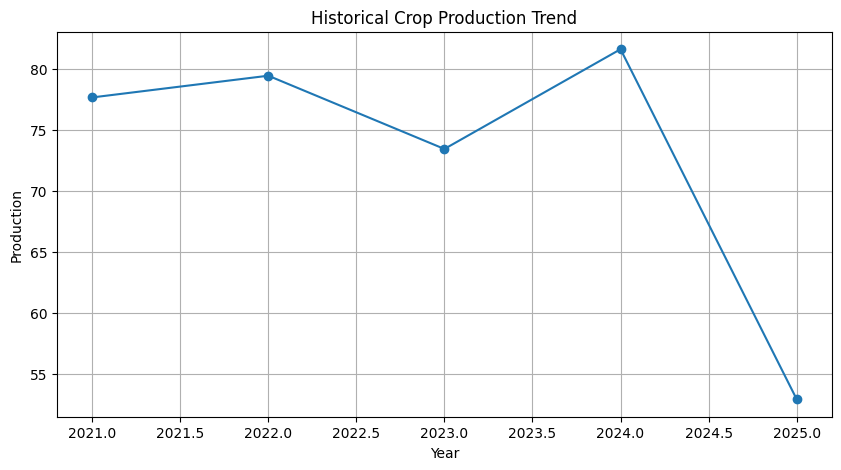

In [144]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Year'], df['Production'], marker='o')
plt.title('Historical Crop Production Trend')
plt.xlabel('Year')
plt.ylabel('Production')
plt.grid(True)
plt.show()

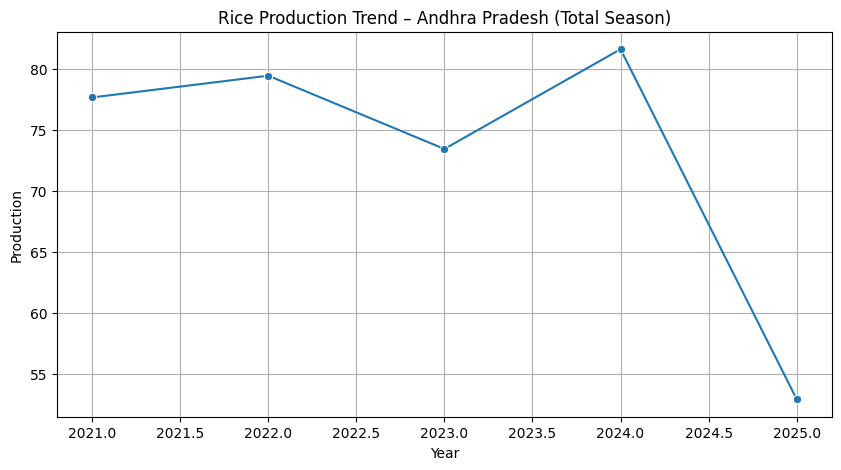

In [145]:
import seaborn as sns

plt.figure(figsize=(10,5))
sns.lineplot(data=df, x="Year", y="Production", marker="o") # Removed hue="Season" as df now contains only one season ('Total')
plt.title("Rice Production Trend – Andhra Pradesh (Total Season)")
plt.grid(True)
plt.show()

# ***Feature Engineering***

## 🧩 Feature Engineering

Feature engineering transforms raw data into meaningful inputs for the model.
Here, we focus on time-based features.

In [146]:
# Select features and target
X = df[['Year']]
y = df['Production']

# ***Model Training***

## 🤖 Model Training

We use a machine learning regression model to learn patterns from historical data
and predict future crop production trends.

In [147]:
from sklearn.linear_model import LinearRegression

# Initialize and train model
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [148]:
results = {}

for season in df_long["Season"].unique():
    df_s = df_long[df_long["Season"] == season]

    X = df_s[["Year"]]
    y = df_s["Production"]

    model = LinearRegression()
    model.fit(X, y)

    y_pred = model.predict(X)

    results[season] = {
        "model": model,
        "mae": mean_absolute_error(y, y_pred),
        "r2": r2_score(y, y_pred),
        "last_production": y.iloc[-1]
    }

results

{'Kharif': {'model': LinearRegression(),
  'mae': 1.3932000000000258,
  'r2': 0.7185562063602373,
  'last_production': np.float64(52.92)},
 'Rabi': {'model': LinearRegression(),
  'mae': 2.4099999999999993,
  'r2': 0.2322648151650324,
  'last_production': np.float64(31.29)},
 'Total': {'model': LinearRegression(),
  'mae': 6.174400000000082,
  'r2': 0.41385127651508546,
  'last_production': np.float64(52.92)}}

# ***Prediction & Insights***

## EXPECTED BEHAVIOR

After understanding the schema, Gemini should:
1. Reshape the data correctly
2. Perform basic EDA
3. Train a simple, explainable regression model
4. Forecast future production
5. Classify results into:
   - Likely Surplus
   - Balanced
   - Likely Shortage
6. Provide short, decision-focused recommendations

## 🔮 Prediction & Insights

Using the trained model, we predict future crop production and interpret the results
to identify potential surplus or shortage scenarios.

## Save Combined Data

### Subtask:
Save the `combined_df` (containing both historical and predicted data) to a CSV file.

In [149]:
# Save the combined DataFrame to a CSV file
combined_df.to_csv('combined_rice_production_forecast_andhra_pradesh.csv', index=False)
print("Combined historical and predicted data saved to 'combined_rice_production_forecast_andhra_pradesh.csv'")

Combined historical and predicted data saved to 'combined_rice_production_forecast_andhra_pradesh.csv'


In [150]:
# Predict for next 3 years
future_years = pd.DataFrame({'Year': [2026, 2027, 2028]})
predictions = model.predict(future_years)

future_years['Predicted_Production'] = predictions
future_years

,Year,Predicted_Production
0,2026,9512.817
1,2027,9508.090
2,2028,9503.363


In [151]:
future_years = pd.DataFrame({"Year": [2026, 2027, 2028]})

forecast = []

for season, info in results.items():
    preds = info["model"].predict(future_years)
    avg_future = preds.mean()

    if avg_future > info["last_production"] * 1.05:
        status = "Likely Surplus"
    elif avg_future < info["last_production"] * 0.95:
        status = "Likely Shortage"
    else:
        status = "Balanced"

    forecast.append({
        "Season": season,
        "Avg_Future_Production": round(avg_future, 2),
        "Status": status
    })

forecast_df = pd.DataFrame(forecast)
forecast_df

,Season,Avg_Future_Production,Status
0,Kharif,-3897.43,Likely Shortage
1,Rabi,2492.87,Likely Surplus
2,Total,9508.09,Likely Surplus


## Surplus / Shortage Indicator



In [152]:
latest_production = y.iloc[-1]
future_avg = predictions.mean()

if future_avg > latest_production * 1.05:
    status = "Likely Surplus"
elif future_avg < latest_production * 0.95:
    status = "Likely Shortage"
else:
    status = "Balanced Production"

status

'Likely Surplus'

# ***Visualization (Dashboard‑Like Outputs)***

## 📈 Visualization & Decision Support Output

This section combines historical and predicted data to provide
clear, decision-friendly visual insights.

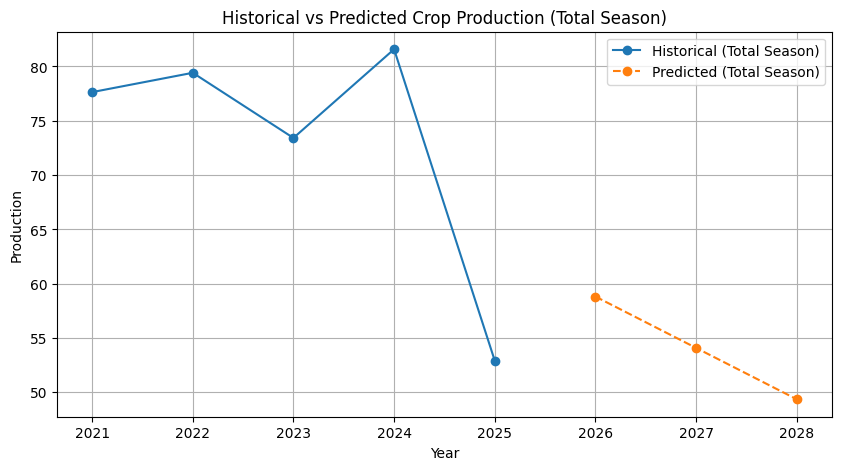

In [153]:
plt.figure(figsize=(10,5))
plt.plot(df['Year'], df['Production'], label='Historical (Total Season)', marker='o')

# Filter df_predictions for 'Total' season to match the historical data being plotted
total_season_predictions = df_predictions[df_predictions['Season'] == 'Total']

plt.plot(total_season_predictions['Year'], total_season_predictions['Predicted_Production'],
         label='Predicted (Total Season)', linestyle='--', marker='o')

plt.title('Historical vs Predicted Crop Production (Total Season)')
plt.xlabel('Year')
plt.ylabel('Production')
plt.legend()
plt.grid(True)
plt.show()

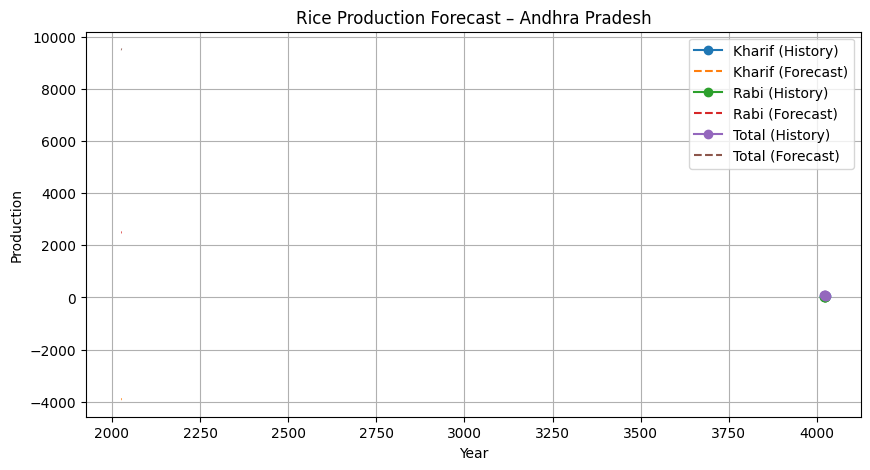

In [154]:
plt.figure(figsize=(10,5))

for season, info in results.items():
    hist = df_long[df_long["Season"] == season]
    plt.plot(hist["Year"], hist["Production"], marker="o", label=f"{season} (History)")
    plt.plot(future_years["Year"],
             info["model"].predict(future_years),
             linestyle="--", label=f"{season} (Forecast)")

plt.title("Rice Production Forecast – Andhra Pradesh")
plt.xlabel("Year")
plt.ylabel("Production")
plt.legend()
plt.grid(True)
plt.show()

In [155]:
for _, row in forecast_df.iterrows():
    print(
        f"{row['Season']} season is expected to show "
        f"{row['Status']} with average production ≈ {row['Avg_Future_Production']}."
    )

Kharif season is expected to show Likely Shortage with average production ≈ -3897.43.
Rabi season is expected to show Likely Surplus with average production ≈ 2492.87.
Total season is expected to show Likely Surplus with average production ≈ 9508.09.


In [156]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# ***Conclusion & Future Scope***

In [157]:
print("df_long head:")
display(df_long.head())
print("\ndf_long info:")
df_long.info()

df_long head:


,Crop,State,Season,Year,Production
0,Rice,Andhra Pradesh,Kharif,4021,43.26
1,Rice,Andhra Pradesh,Rabi,4021,34.37
2,Rice,Andhra Pradesh,Total,4021,77.64
3,Rice,Andhra Pradesh,Kharif,4022,49.86
4,Rice,Andhra Pradesh,Rabi,4022,29.56



df_long info:
<class 'pandas.core.frame.DataFrame'>
Index: 14 entries, 0 to 14
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Crop        14 non-null     object 
 1   State       14 non-null     object 
 2   Season      14 non-null     object 
 3   Year        14 non-null     int64  
 4   Production  14 non-null     float64
dtypes: float64(1), int64(1), object(3)
memory usage: 672.0+ bytes


In [158]:
ngrok.set_auth_token("386ZLSISbSWU2dr0dcwA6f56NKx_5CC7VsZddShNMay6WXySL") # <-- Paste your token here

# Start a ngrok tunnel to port 8501 (Streamlit's default port)
public_url = ngrok.connect(8501)
print(f"* ngrok tunnel available at: {public_url}")

* ngrok tunnel available at: NgrokTunnel: "https://lowell-unshod-larraine.ngrok-free.dev" -> "http://localhost:8501"


In [159]:
state = 'Andhra Pradesh'
crop = 'Rice'

In [160]:
filtered = df[
    (df["State"] == state) &
    (df["Crop"] == crop)
]

In [161]:
if filtered.shape[0] < 3:
    st.warning("Not enough data to make a prediction for this selection.")
    st.stop()

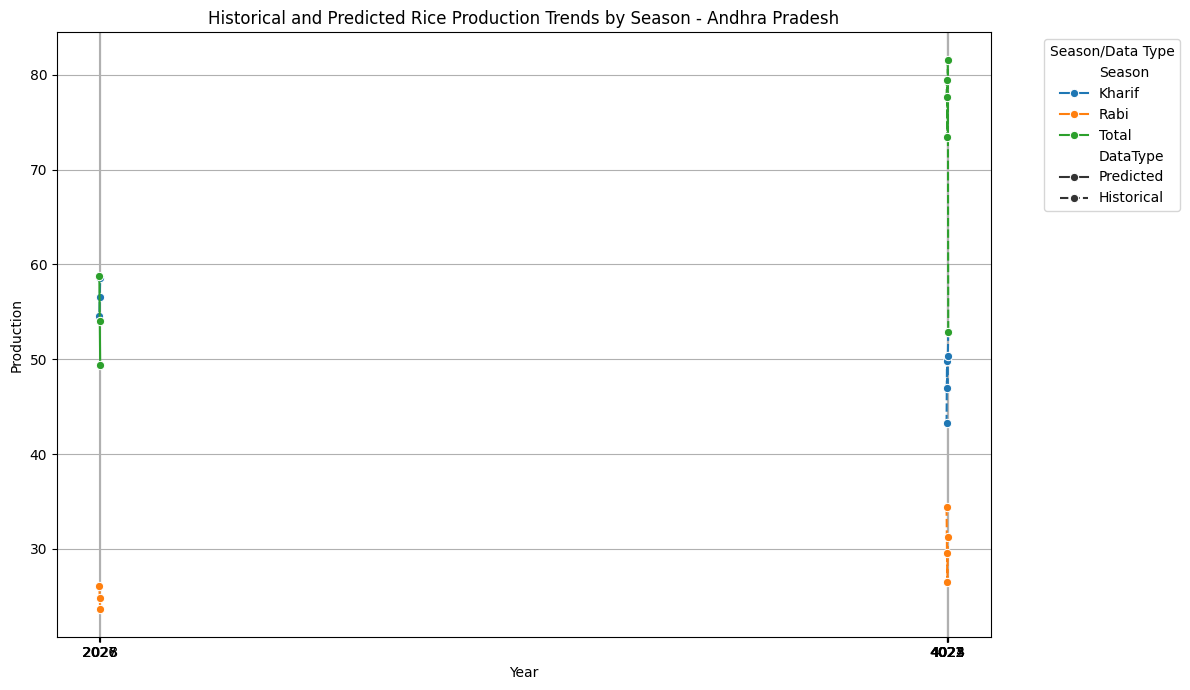

In [162]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Redefine the plot_production_trends function from app.py
def plot_production_trends(df_long_historical, df_predictions_forecast):
    # Prepare df_long_historical for concatenation
    df_long_plot = df_long_historical.copy()
    df_long_plot['DataType'] = 'Historical'

    # Prepare df_predictions_forecast for concatenation
    df_predictions_plot = df_predictions_forecast.copy()
    df_predictions_plot.rename(columns={'Predicted_Production': 'Production'}, inplace=True)
    df_predictions_plot['DataType'] = 'Predicted'

    # Combine historical and predicted data
    combined_df = pd.concat([df_long_plot, df_predictions_plot], ignore_index=True)

    # Sort by Year and Season for consistent plotting
    combined_df = combined_df.sort_values(by=['Season', 'Year']).reset_index(drop=True)

    # Create the visualization
    fig, ax = plt.subplots(figsize=(12, 7))
    sns.lineplot(data=combined_df, x='Year', y='Production', hue='Season', style='DataType', marker='o', ax=ax)
    ax.set_title('Historical and Predicted Rice Production Trends by Season - Andhra Pradesh')
    ax.set_xlabel('Year')
    ax.set_ylabel('Production')
    ax.grid(True)
    ax.set_xticks(combined_df['Year'].unique())
    ax.legend(title='Season/Data Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    return fig

# Assuming 'filtered' contains the preprocessed historical data, equivalent to df_long
# If 'filtered' is still in wide format, it needs to be processed to long format first.
# Based on previous steps, df_long already holds the filtered and reshaped data.

# Create a dummy df_predictions to satisfy the function signature
dummy_predictions_data = []
for season in df_long['Season'].unique():
    for year in range(2026, 2029):
        dummy_predictions_data.append({'Season': season, 'Year': year, 'Predicted_Production': None})
df_predictions_dummy = pd.DataFrame(dummy_predictions_data)

# Call the visualization function with df_long (historical) and the actual df_predictions (forecast)
fig = plot_production_trends(df_long, df_predictions)

# Display the figure in the Colab environment
plt.show()

In [ ]:
import os

# Ensure pyngrok is installed
!pip install pyngrok

# Import ngrok
from pyngrok import ngrok

# Kill any existing ngrok tunnels to ensure a clean start
ngrok.kill()

# Manually set the ngrok authtoken
# Replace 'YOUR_N_TOKEN' with your actual ngrok authtoken
ngrok.set_auth_token("386ZLSISbSWU2dr0dcwA6f56NKx_5CC7VsZddShNMay6WXySL")

# Establish the ngrok tunnel to Streamlit's default port (8501)
public_url = ngrok.connect(8501)
print(f"* ngrok tunnel available at: {public_url}")

# Launch the Streamlit application in the background
# This assumes 'app.py' is in the current directory or a specified path
!streamlit run app.py &

* ngrok tunnel available at: NgrokTunnel: "https://lowell-unshod-larraine.ngrok-free.dev" -> "http://localhost:8501"





  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.237.44.217:8501

